# 딥러닝 오버피팅 방지 기법 실습 - PyTorch 버전


> 이 노트북은 오버피팅을 직접 확인하고, 방지 기법을 적용한 모델과 비교하는 실습입니다.  

## 실습 목표

1. 작은 학습 데이터에서 오버피팅이 어떻게 나타나는지 확인합니다.
2. Train Loss와 Validation Loss 차이를 그래프로 비교합니다.
3. 다음 오버피팅 방지 기법을 코드로 적용합니다.
   - 데이터 증강(Data Augmentation)
   - Dropout
   - Batch Normalization
   - Weight Decay
   - Early Stopping
   - Label Smoothing
   - 모델 단순화

In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# PyTorch의 핵심 패키지를 불러옵니다.
# 텐서 생성, GPU 연산, 자동 미분 기능을 사용할 수 있습니다.
import torch

# torch.nn은 신경망 계층, 활성화 함수, 손실 함수 등을 제공합니다.
import torch.nn as nn

# torch.optim은 SGD, Adam, AdamW 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# DataLoader는 데이터를 미니배치 단위로 모델에 공급하는 도구입니다.
# Subset은 데이터셋 일부만 선택할 때 사용합니다.
# random_split은 데이터셋을 학습용과 검증용으로 나눌 때 사용합니다.
from torch.utils.data import DataLoader, Subset, random_split

# torchvision.datasets는 Fashion-MNIST 같은 예제 이미지 데이터셋을 제공합니다.
# torchvision.transforms는 이미지 전처리와 데이터 증강 기능을 제공합니다.
from torchvision import datasets, transforms

# numpy는 평균, 배열 처리 등 수치 계산을 위해 사용합니다.
import numpy as np

# matplotlib.pyplot은 학습 결과 그래프를 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# random은 파이썬 기본 난수 생성을 제어하기 위해 사용합니다.
import random

# ============================================================
# 2. 실험 결과를 최대한 일정하게 만들기 위한 시드 고정
# ============================================================

# SEED 값은 난수 생성의 시작점을 의미합니다.
# 같은 SEED를 사용하면 데이터 분할과 초기값이 비교적 일정하게 유지됩니다.
SEED = 42

# 파이썬 random 모듈의 난수 시드를 고정합니다.
random.seed(SEED)

# numpy 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 연산의 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# PyTorch GPU 연산의 난수 시드를 고정합니다.
torch.cuda.manual_seed_all(SEED)

# GPU가 사용 가능하면 cuda를 사용하고, 그렇지 않으면 cpu를 사용합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 현재 어떤 장치에서 학습하는지 출력합니다.
print('사용 장치:', device)

사용 장치: cpu


## 1단계: Fashion-MNIST 데이터 준비

Fashion-MNIST는 티셔츠, 바지, 신발 등 10개 의류 클래스를 분류하는 이미지 데이터셋입니다.  
오버피팅을 쉽게 관찰하기 위해 전체 학습 데이터 중 일부만 사용합니다.

In [2]:
# ============================================================
# 3. 기본 전처리 정의
# ============================================================

# transforms.Compose는 여러 전처리 작업을 순서대로 묶어줍니다.
basic_transform = transforms.Compose([
    # 이미지를 PyTorch 텐서로 변환합니다.
    # 픽셀값은 0~255 범위에서 0~1 범위로 자동 변환됩니다.
    transforms.ToTensor(),

    # 입력값을 평균 0.5, 표준편차 0.5 기준으로 정규화합니다.
    # 0~1 범위의 픽셀값이 대략 -1~1 범위로 변환됩니다.
    transforms.Normalize((0.5,), (0.5,))
])

# ============================================================
# 4. 데이터 증강 전처리 정의
# ============================================================

# 데이터 증강은 기존 이미지를 조금씩 변형하여 새로운 데이터처럼 사용하는 기법입니다.
aug_transform = transforms.Compose([
    # 이미지를 -10도에서 +10도 사이로 무작위 회전합니다.
    # 모델이 회전된 이미지에도 잘 대응하도록 돕습니다.
    transforms.RandomRotation(degrees=10),

    # 이미지를 가로/세로 방향으로 최대 10% 정도 무작위 이동합니다.
    # 모델이 물체의 위치 변화에 덜 민감해지도록 합니다.
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),

    # 증강된 이미지를 PyTorch 텐서로 변환합니다.
    transforms.ToTensor(),

    # 증강된 이미지도 기본 데이터와 같은 방식으로 정규화합니다.
    transforms.Normalize((0.5,), (0.5,))
])

# ============================================================
# 5. Fashion-MNIST 데이터셋 다운로드 및 생성
# ============================================================

# 기본 전처리만 적용한 학습 데이터셋을 생성합니다.
full_train_basic = datasets.FashionMNIST(
    root='./data',              # 데이터가 저장될 폴더입니다.
    train=True,                 # 학습용 데이터를 불러옵니다.
    download=True,              # 데이터가 없으면 자동 다운로드합니다.
    transform=basic_transform   # 기본 전처리를 적용합니다.
)

# 데이터 증강 전처리를 적용한 학습 데이터셋을 생성합니다.
full_train_aug = datasets.FashionMNIST(
    root='./data',            # 데이터 저장 폴더입니다.
    train=True,               # 학습용 데이터를 불러옵니다.
    download=True,            # 데이터가 없으면 자동 다운로드합니다.
    transform=aug_transform   # 데이터 증강 전처리를 적용합니다.
)

# 테스트 데이터셋은 최종 평가용으로 사용합니다.
# 테스트 데이터에는 데이터 증강을 적용하지 않습니다.
test_dataset = datasets.FashionMNIST(
    root='./data',              # 데이터 저장 폴더입니다.
    train=False,                # 테스트용 데이터를 불러옵니다.
    download=True,              # 데이터가 없으면 자동 다운로드합니다.
    transform=basic_transform   # 평가 데이터에는 기본 전처리만 적용합니다.
)

# ============================================================
# 6. 일부 데이터만 사용하여 오버피팅 상황 만들기
# ============================================================

# 전체 60,000개 학습 데이터 중 앞쪽 3,000개만 선택합니다.
# 데이터 수를 줄이면 모델이 학습 데이터를 외우는 현상이 더 잘 보입니다.
small_indices = list(range(3000))

# 기본 전처리 데이터셋에서 3,000개만 선택합니다.
small_basic = Subset(full_train_basic, small_indices)

# 데이터 증강 데이터셋에서도 같은 개수만 선택합니다.
small_aug = Subset(full_train_aug, small_indices)

# 3,000개 중 2,400개는 학습용으로 사용합니다.
train_size = 2400

# 3,000개 중 600개는 검증용으로 사용합니다.
val_size = 600

# 데이터 분할 결과를 일정하게 만들기 위해 PyTorch Generator에 시드를 설정합니다.
generator = torch.Generator().manual_seed(SEED)

# 기본 데이터셋을 학습용과 검증용으로 나눕니다.
train_basic, val_basic = random_split(small_basic, [train_size, val_size], generator=generator)

# 데이터 증강 데이터셋도 학습용과 검증용으로 나눕니다.
generator = torch.Generator().manual_seed(SEED)
train_aug, val_aug = random_split(small_aug, [train_size, val_size], generator=generator)

# 한 번에 모델에 입력할 데이터 개수입니다.
BATCH_SIZE = 64

# 기본 학습 데이터를 미니배치 단위로 불러오는 DataLoader입니다.
train_loader_basic = DataLoader(train_basic, batch_size=BATCH_SIZE, shuffle=True)

# 데이터 증강 학습 데이터를 미니배치 단위로 불러오는 DataLoader입니다.
train_loader_aug = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True)

# 검증 데이터는 순서를 섞을 필요가 없으므로 shuffle=False로 설정합니다.
val_loader = DataLoader(val_basic, batch_size=BATCH_SIZE, shuffle=False)

# 테스트 데이터도 평가용이므로 shuffle=False로 설정합니다.
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 학습 데이터 개수를 출력합니다.
print('\n학습 데이터 수:', len(train_basic))

# 검증 데이터 개수를 출력합니다.
print('검증 데이터 수:', len(val_basic))

# 테스트 데이터 개수를 출력합니다.
print('테스트 데이터 수:', len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.3MB/s]



학습 데이터 수: 2400
검증 데이터 수: 600
테스트 데이터 수: 10000


## 2단계: 오버피팅 모델과 방지 기법 적용 모델 정의

첫 번째 모델은 일부러 복잡하게 만들어 오버피팅을 관찰합니다.  
두 번째 모델은 Dropout, Batch Normalization, 모델 단순화 등을 적용합니다.

In [3]:
# ============================================================
# 7. 오버피팅 관찰용 복잡한 모델 정의
# ============================================================

# nn.Module을 상속하면 PyTorch 신경망 모델 클래스를 만들 수 있습니다.
class OverfitMLP(nn.Module):
    # __init__ 메서드는 모델의 계층을 정의하는 부분입니다.
    def __init__(self):
        # 부모 클래스인 nn.Module의 초기화 기능을 실행합니다.
        super().__init__()

        # nn.Sequential은 여러 계층을 순서대로 실행하는 컨테이너입니다.
        self.net = nn.Sequential(
            # 28x28 이미지를 784개의 숫자로 펼칩니다.
            nn.Flatten(),

            # 입력 784개를 1024개 특징으로 변환합니다.
            # 데이터가 적은 상황에서는 이렇게 큰 계층이 오버피팅을 유발할 수 있습니다.
            nn.Linear(28 * 28, 1024),

            # ReLU는 음수는 0으로, 양수는 그대로 통과시키는 활성화 함수입니다.
            nn.ReLU(),

            # 1024개 특징을 512개 특징으로 변환합니다.
            nn.Linear(1024, 512),

            # 두 번째 ReLU 활성화 함수입니다.
            nn.ReLU(),

            # 512개 특징을 256개 특징으로 변환합니다.
            nn.Linear(512, 256),

            # 세 번째 ReLU 활성화 함수입니다.
            nn.ReLU(),

            # 256개 특징을 최종 클래스 10개 점수로 변환합니다.
            nn.Linear(256, 10)
        )

    # forward 메서드는 입력 데이터가 모델을 통과하는 계산 흐름을 정의합니다.
    def forward(self, x):
        # 입력 x를 self.net에 넣고 출력 결과를 반환합니다.
        return self.net(x)

# ============================================================
# 8. 오버피팅 방지 기법 적용 모델 정의
# ============================================================

# 정규화 기법이 포함된 비교 모델입니다.
class RegularizedMLP(nn.Module):
    # 모델 계층을 정의합니다.
    def __init__(self):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # 여러 계층을 순서대로 실행하도록 정의합니다.
        self.net = nn.Sequential(
            # 이미지를 1차원 벡터로 펼칩니다.
            nn.Flatten(),

            # 복잡한 모델보다 작은 256개 은닉 뉴런을 사용합니다.
            # 모델 단순화는 오버피팅을 줄이는 기본 방법입니다.
            nn.Linear(28 * 28, 256),

            # BatchNorm1d는 은닉층 출력 분포를 안정화합니다.
            # 학습 안정화와 약한 정규화 효과를 기대할 수 있습니다.
            nn.BatchNorm1d(256),

            # ReLU 활성화 함수입니다.
            nn.ReLU(),

            # Dropout은 학습 중 일부 뉴런을 무작위로 끕니다.
            # 특정 뉴런에만 의존하는 것을 막아 오버피팅을 줄입니다.
            nn.Dropout(p=0.5),

            # 256개 특징을 128개 특징으로 줄입니다.
            nn.Linear(256, 128),

            # 두 번째 배치 정규화입니다.
            nn.BatchNorm1d(128),

            # 두 번째 ReLU 활성화 함수입니다.
            nn.ReLU(),

            # 두 번째 Dropout입니다.
            nn.Dropout(p=0.3),

            # 최종 10개 클래스 점수를 출력합니다.
            nn.Linear(128, 10)
        )

    # 입력 데이터의 순전파 과정을 정의합니다.
    def forward(self, x):
        # 입력 x를 네트워크에 통과시켜 예측 점수를 반환합니다.
        return self.net(x)

## 3단계: 학습 함수와 평가 함수 정의

같은 함수를 사용해 두 모델을 학습합니다.  
이렇게 하면 오버피팅 방지 기법 적용 전후를 공정하게 비교할 수 있습니다.

In [4]:
# ============================================================
# 9. 한 epoch 동안 학습하는 함수 정의
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    # 모델을 학습 모드로 전환합니다.
    # Dropout과 BatchNorm은 학습 모드와 평가 모드에서 동작이 다릅니다.
    model.train()

    # 한 epoch 동안의 전체 손실 합계를 저장할 변수입니다.
    total_loss = 0.0

    # 맞게 예측한 데이터 개수를 저장할 변수입니다.
    correct = 0

    # 전체 데이터 개수를 저장할 변수입니다.
    total = 0

    # DataLoader에서 미니배치 단위로 이미지와 정답을 꺼냅니다.
    for images, labels in loader:
        # 이미지를 GPU 또는 CPU 장치로 이동합니다.
        images = images.to(device)

        # 정답 라벨도 같은 장치로 이동합니다.
        labels = labels.to(device)

        # 이전 미니배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad()

        # 모델에 이미지를 입력하여 예측 점수를 계산합니다.
        outputs = model(images)

        # 예측 점수와 정답 라벨을 비교하여 손실값을 계산합니다.
        loss = criterion(outputs, labels)

        # 손실값을 기준으로 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델 파라미터를 업데이트합니다.
        optimizer.step()

        # 현재 미니배치 손실에 데이터 개수를 곱해 누적합니다.
        total_loss += loss.item() * images.size(0)

        # 가장 점수가 높은 클래스를 예측 결과로 선택합니다.
        _, preds = torch.max(outputs, 1)

        # 예측값과 정답이 같은 개수를 누적합니다.
        correct += (preds == labels).sum().item()

        # 전체 데이터 개수를 누적합니다.
        total += labels.size(0)

    # 평균 손실을 계산합니다.
    avg_loss = total_loss / total

    # 정확도를 계산합니다.
    accuracy = correct / total

    # 평균 손실과 정확도를 반환합니다.
    return avg_loss, accuracy

# ============================================================
# 10. 검증 또는 테스트를 수행하는 함수 정의
# ============================================================

def evaluate(model, loader, criterion):
    # 모델을 평가 모드로 전환합니다.
    # 평가 모드에서는 Dropout이 꺼지고 BatchNorm은 저장된 통계를 사용합니다.
    model.eval()

    # 전체 손실 합계를 저장합니다.
    total_loss = 0.0

    # 맞게 예측한 개수를 저장합니다.
    correct = 0

    # 전체 데이터 개수를 저장합니다.
    total = 0

    # 평가 단계에서는 기울기 계산이 필요하지 않습니다.
    # torch.no_grad()를 사용하면 메모리 사용량과 계산량이 줄어듭니다.
    with torch.no_grad():
        # DataLoader에서 미니배치를 하나씩 가져옵니다.
        for images, labels in loader:
            # 이미지를 연산 장치로 이동합니다.
            images = images.to(device)

            # 라벨을 연산 장치로 이동합니다.
            labels = labels.to(device)

            # 모델 예측 점수를 계산합니다.
            outputs = model(images)

            # 손실값을 계산합니다.
            loss = criterion(outputs, labels)

            # 손실 합계를 누적합니다.
            total_loss += loss.item() * images.size(0)

            # 가장 높은 점수의 클래스를 예측값으로 선택합니다.
            _, preds = torch.max(outputs, 1)

            # 정답과 같은 예측 개수를 누적합니다.
            correct += (preds == labels).sum().item()

            # 전체 라벨 개수를 누적합니다.
            total += labels.size(0)

    # 평균 손실을 계산합니다.
    avg_loss = total_loss / total

    # 정확도를 계산합니다.
    accuracy = correct / total

    # 평균 손실과 정확도를 반환합니다.
    return avg_loss, accuracy

## 4단계: Early Stopping이 포함된 전체 학습 함수 정의

Early Stopping은 검증 손실이 더 이상 좋아지지 않으면 학습을 중단합니다.  
오버피팅이 심해지기 전에 가장 좋은 모델 상태를 복원하는 데 사용합니다.

In [5]:
# ============================================================
# 11. 전체 학습 함수 정의
# ============================================================

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=30, patience=None):
    # epoch별 학습/검증 손실과 정확도를 저장할 딕셔너리입니다.
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # Early Stopping에서 가장 낮은 검증 손실을 저장합니다.
    best_val_loss = float('inf')

    # 가장 좋은 모델의 파라미터를 저장할 변수입니다.
    best_state = None

    # 검증 손실이 개선되지 않은 epoch 수를 세는 변수입니다.
    patience_counter = 0

    # 지정한 epoch 수만큼 학습을 반복합니다.
    for epoch in range(1, epochs + 1):
        # 한 epoch 동안 학습을 수행하고 학습 손실과 정확도를 얻습니다.
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

        # 검증 데이터로 모델 성능을 평가합니다.
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        # 학습 손실을 기록합니다.
        history['train_loss'].append(train_loss)

        # 학습 정확도를 기록합니다.
        history['train_acc'].append(train_acc)

        # 검증 손실을 기록합니다.
        history['val_loss'].append(val_loss)

        # 검증 정확도를 기록합니다.
        history['val_acc'].append(val_acc)

        # 현재 epoch 결과를 출력합니다.
        print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        # Early Stopping을 사용하는 경우에만 아래 로직을 실행합니다.
        if patience is not None:
            # 검증 손실이 이전보다 좋아졌는지 확인합니다.
            if val_loss < best_val_loss:
                # 가장 좋은 검증 손실을 갱신합니다.
                best_val_loss = val_loss

                # 현재 모델 파라미터를 CPU 기준 딕셔너리로 복사해 저장합니다.
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

                # 개선되었으므로 카운터를 0으로 초기화합니다.
                patience_counter = 0
            else:
                # 개선되지 않았으므로 카운터를 1 증가시킵니다.
                patience_counter += 1

                # 개선되지 않은 횟수가 patience 이상이면 학습을 중단합니다.
                if patience_counter >= patience:
                    # Early Stopping이 발생했음을 출력합니다.
                    print(f'Early Stopping 발생: {epoch}번째 epoch에서 학습 중단')

                    # 반복문을 종료합니다.
                    break

    # Early Stopping을 사용했고 가장 좋은 모델 상태가 저장되어 있다면 복원합니다.
    if best_state is not None:
        # 저장된 최적 파라미터를 모델에 다시 적용합니다.
        model.load_state_dict(best_state)

        # 모델을 현재 장치로 이동합니다.
        model.to(device)

    # 학습 기록을 반환합니다.
    return history

## 5단계: 기준 모델 학습 - 오버피팅 확인

복잡한 모델을 작은 데이터로 오래 학습하면 학습 성능은 높아지지만 검증 성능은 정체되거나 나빠질 수 있습니다.

In [6]:
# ============================================================
# 12. 오버피팅 관찰용 모델 학습
# ============================================================

# 복잡한 MLP 모델 객체를 생성하고 GPU 또는 CPU로 이동합니다.
overfit_model = OverfitMLP().to(device)

# CrossEntropyLoss는 다중 분류 문제에서 사용하는 대표적인 손실 함수입니다.
criterion_basic = nn.CrossEntropyLoss()

# Adam 최적화 알고리즘을 사용합니다.
# 여기서는 weight_decay를 적용하지 않아 정규화 효과가 없습니다.
optimizer_basic = optim.Adam(overfit_model.parameters(), lr=0.001)

# 기준 모델을 학습합니다.
# Early Stopping 없이 30 epoch 동안 학습하여 오버피팅 경향을 관찰합니다.
history_overfit = train_model(
    model=overfit_model,
    train_loader=train_loader_basic,
    val_loader=val_loader,
    criterion=criterion_basic,
    optimizer=optimizer_basic,
    epochs=30,
    patience=None
)

Epoch 01 | Train Loss: 1.0098 | Train Acc: 0.6454 | Val Loss: 0.8607 | Val Acc: 0.6417
Epoch 02 | Train Loss: 0.5835 | Train Acc: 0.7804 | Val Loss: 0.6982 | Val Acc: 0.7300
Epoch 03 | Train Loss: 0.4993 | Train Acc: 0.8175 | Val Loss: 0.6409 | Val Acc: 0.7667
Epoch 04 | Train Loss: 0.4405 | Train Acc: 0.8375 | Val Loss: 0.6413 | Val Acc: 0.7700
Epoch 05 | Train Loss: 0.3877 | Train Acc: 0.8625 | Val Loss: 0.6021 | Val Acc: 0.7967
Epoch 06 | Train Loss: 0.3389 | Train Acc: 0.8767 | Val Loss: 0.6172 | Val Acc: 0.7933
Epoch 07 | Train Loss: 0.3582 | Train Acc: 0.8721 | Val Loss: 0.6738 | Val Acc: 0.7800
Epoch 08 | Train Loss: 0.3335 | Train Acc: 0.8833 | Val Loss: 0.6786 | Val Acc: 0.7767
Epoch 09 | Train Loss: 0.2832 | Train Acc: 0.8958 | Val Loss: 0.7495 | Val Acc: 0.7633
Epoch 10 | Train Loss: 0.2661 | Train Acc: 0.9054 | Val Loss: 0.6854 | Val Acc: 0.7850
Epoch 11 | Train Loss: 0.2611 | Train Acc: 0.9004 | Val Loss: 0.7533 | Val Acc: 0.7750
Epoch 12 | Train Loss: 0.2270 | Train Acc: 

## 6단계: 오버피팅 방지 기법 적용 모델 학습

다음 학습에는 여러 방지 기법이 함께 적용됩니다.

- 데이터 증강: `train_loader_aug`
- Dropout: `RegularizedMLP` 내부
- Batch Normalization: `RegularizedMLP` 내부
- Weight Decay: `AdamW(weight_decay=0.01)`
- Early Stopping: `patience=5`
- Label Smoothing: `CrossEntropyLoss(label_smoothing=0.1)`
- 모델 단순화: 은닉층 크기 축소

In [7]:
# ============================================================
# 13. 오버피팅 방지 기법 적용 모델 학습
# ============================================================

# 정규화 기법이 포함된 MLP 모델을 생성하고 연산 장치로 이동합니다.
regularized_model = RegularizedMLP().to(device)

# label_smoothing=0.1은 정답 라벨을 100% 확신하지 않도록 부드럽게 만듭니다.
# 모델이 학습 데이터의 정답을 지나치게 강하게 외우는 것을 줄이는 데 도움이 됩니다.
criterion_regularized = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW는 Adam에 Weight Decay를 안정적으로 적용하는 최적화 알고리즘입니다.
# weight_decay=0.01은 가중치가 과도하게 커지는 것을 억제합니다.
optimizer_regularized = optim.AdamW(
    regularized_model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

# 정규화 모델을 학습합니다.
# 데이터 증강 학습 로더를 사용하고, Early Stopping을 적용합니다.
history_regularized = train_model(
    model=regularized_model,
    train_loader=train_loader_aug,
    val_loader=val_loader,
    criterion=criterion_regularized,
    optimizer=optimizer_regularized,
    epochs=30,
    patience=5
)

Epoch 01 | Train Loss: 1.6680 | Train Acc: 0.4979 | Val Loss: 1.3476 | Val Acc: 0.6183
Epoch 02 | Train Loss: 1.3467 | Train Acc: 0.6129 | Val Loss: 1.2343 | Val Acc: 0.6567
Epoch 03 | Train Loss: 1.2602 | Train Acc: 0.6508 | Val Loss: 1.2019 | Val Acc: 0.6733
Epoch 04 | Train Loss: 1.2320 | Train Acc: 0.6758 | Val Loss: 1.1531 | Val Acc: 0.6983
Epoch 05 | Train Loss: 1.2032 | Train Acc: 0.6700 | Val Loss: 1.1514 | Val Acc: 0.6783
Epoch 06 | Train Loss: 1.1851 | Train Acc: 0.6850 | Val Loss: 1.1214 | Val Acc: 0.7183
Epoch 07 | Train Loss: 1.1856 | Train Acc: 0.6854 | Val Loss: 1.1134 | Val Acc: 0.6950
Epoch 08 | Train Loss: 1.1689 | Train Acc: 0.6937 | Val Loss: 1.1034 | Val Acc: 0.7100
Epoch 09 | Train Loss: 1.1725 | Train Acc: 0.6937 | Val Loss: 1.0943 | Val Acc: 0.7167
Epoch 10 | Train Loss: 1.1572 | Train Acc: 0.7096 | Val Loss: 1.1089 | Val Acc: 0.7050
Epoch 11 | Train Loss: 1.1492 | Train Acc: 0.7046 | Val Loss: 1.0951 | Val Acc: 0.7250
Epoch 12 | Train Loss: 1.1494 | Train Acc: 

## 7단계: 학습 결과 그래프로 비교

오버피팅이 발생하면 보통 Train Loss는 계속 감소하지만 Validation Loss는 다시 증가하거나 정체됩니다.

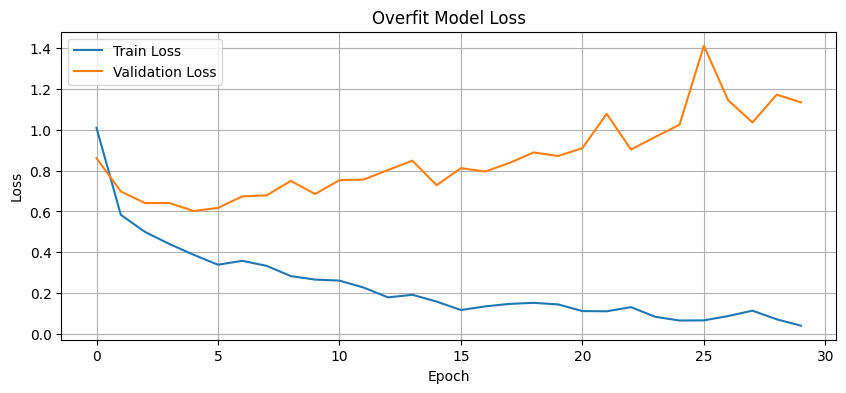

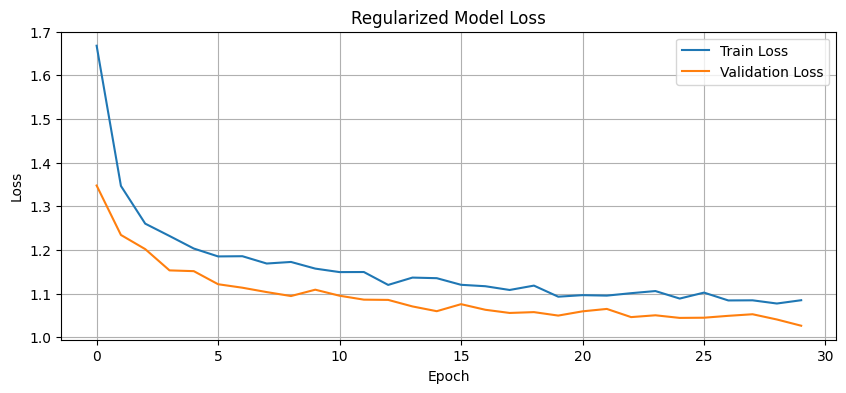

In [8]:
# ============================================================
# 14. 학습 곡선 시각화 함수 정의
# ============================================================

def plot_history(history, title):
    # 그래프 크기를 설정합니다.
    plt.figure(figsize=(10, 4))

    # 학습 손실 그래프를 그립니다.
    plt.plot(history['train_loss'], label='Train Loss')

    # 검증 손실 그래프를 그립니다.
    plt.plot(history['val_loss'], label='Validation Loss')

    # 그래프 제목을 설정합니다.
    plt.title(title)

    # x축 이름을 설정합니다.
    plt.xlabel('Epoch')

    # y축 이름을 설정합니다.
    plt.ylabel('Loss')

    # 범례를 표시합니다.
    plt.legend()

    # 격자선을 표시하여 값을 읽기 쉽게 합니다.
    plt.grid(True)

    # 그래프를 화면에 출력합니다.
    plt.show()

# 오버피팅 관찰용 모델의 손실 변화를 출력합니다.
plot_history(history_overfit, 'Overfit Model Loss')

# 오버피팅 방지 기법 적용 모델의 손실 변화를 출력합니다.
plot_history(history_regularized, 'Regularized Model Loss')

## 8단계: 테스트 데이터로 최종 비교

테스트 데이터는 학습과 검증에 사용하지 않은 새로운 데이터입니다.  
따라서 테스트 성능은 모델의 일반화 성능을 확인하는 데 사용합니다.

In [9]:
# ============================================================
# 15. 테스트 데이터 최종 평가
# ============================================================

# 기준 모델을 테스트 데이터로 평가합니다.
test_loss_overfit, test_acc_overfit = evaluate(overfit_model, test_loader, criterion_basic)

# 정규화 모델을 테스트 데이터로 평가합니다.
test_loss_regularized, test_acc_regularized = evaluate(regularized_model, test_loader, criterion_regularized)

# 기준 모델 테스트 결과를 출력합니다.
print(f'오버피팅 관찰용 모델 - Test Loss: {test_loss_overfit:.4f}, Test Acc: {test_acc_overfit:.4f}')

# 정규화 모델 테스트 결과를 출력합니다.
print(f'오버피팅 방지 적용 모델 - Test Loss: {test_loss_regularized:.4f}, Test Acc: {test_acc_regularized:.4f}')

오버피팅 관찰용 모델 - Test Loss: 0.9939, Test Acc: 0.8137
오버피팅 방지 적용 모델 - Test Loss: 0.9788, Test Acc: 0.7728


## 결과 해석 방법

- `Train Loss`만 계속 낮아지고 `Validation Loss`가 높아지면 오버피팅 가능성이 큽니다.
- 정규화 모델은 학습 정확도가 기준 모델보다 낮을 수 있습니다.
- 하지만 검증 또는 테스트 정확도가 더 안정적이면 일반화 성능이 좋아진 것입니다.
- 데이터 증강, Dropout, Weight Decay, Early Stopping은 각각 따로도 사용할 수 있지만 실무에서는 함께 사용하는 경우가 많습니다.